In [ ]:
# ======================================================
# 🧩 1. IMPORTS & INITIAL SETUP
# ======================================================
import os
import sys
import csv
import importlib
from datetime import datetime
from PIL import ImageFile
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import numpy as np

# additional imports for EfficientNet
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# FIX TRUNCATED/CORRUPTED IMAGES
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ======================================================
# 🌐 2. LOAD LOCAL PREPROCESSING SCRIPT
# ======================================================
PREPROCESSING_PATH = '/content/preprocessing_leukemia_imagenet_2.py'
sys.path.append(os.path.dirname(PREPROCESSING_PATH))

import preprocessing_leukemia_imagenet_2
importlib.reload(preprocessing_leukemia_imagenet_2)
from preprocessing_leukemia_imagenet_2 import preprocess_leukemia_dataset

# ======================================================
# 💾 3. MOUNT GOOGLE DRIVE
# ======================================================
drive.mount('/content/drive')

# DEFINE PATHS
RAW_DATA_DIR = '/content/drive/MyDrive/Research/DataFolder'
DEST_DIR = '/content/drive/MyDrive/Research/leukemia_cleaned_efficientnet'
RESULTS_DIR = '/content/drive/MyDrive/Research/Results_efficientnet'
LOG_FILE = os.path.join(RESULTS_DIR, 'training_logs.csv')

os.makedirs(DEST_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ======================================================
# 🧼 4. RUN PREPROCESSING (use 224x224 for EfficientNetB0)
# ======================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen, val_gen, test_gen = preprocess_leukemia_dataset(
    input_path=RAW_DATA_DIR,
    output_path=DEST_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ======================================================
# 🏗️ 5. MODEL DEVELOPMENT (EfficientNetB0 transfer learning)
# ======================================================
def build_efficientnet_binary_model(input_shape=(224,224,3), lr=1e-3, freeze_base=False):
    """
    Build EfficientNetB0 model for binary classification
    IMPROVEMENTS:
    - Higher learning rate (1e-3 instead of 1e-4)
    - Unfreeze base layers for fine-tuning
    - Deeper classification head
    - Batch normalization for stability
    - Class weights to handle imbalance
    """
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)

    # UNFREEZE base layers for better learning
    if not freeze_base:
        # Fine-tune from layer 100 onwards (keep early layers frozen)
        for layer in base.layers[:100]:
            layer.trainable = False
        for layer in base.layers[100:]:
            layer.trainable = True
    else:
        for layer in base.layers:
            layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)

    # Deeper classification head
    x = Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=outputs)

    # Use higher learning rate with fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(name='Precision'), Recall(name='Recall')]
    )
    return model

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f"Class weights: {class_weight_dict}")

# Build model with fine-tuning enabled
model = build_efficientnet_binary_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    lr=1e-3,  # Higher learning rate
    freeze_base=False  # Enable fine-tuning
)
model.summary()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset reorganized into: ['ALLNeg', 'ALLPos', 'train', 'val', 'test']
✅ Data split into train / val / test folders.
Found 3247 images belonging to 2 classes.
Found 1812 images belonging to 2 classes.
Found 1806 images belonging to 2 classes.
✅ Generators ready.
Class weights: {0: np.float64(3.227634194831014), 1: np.float64(0.5916545189504373)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,840,100 (18.46 MB)

 Trainable params: 4,629,341 (17.66 MB)

 Non-trainable params: 210,759 (823.28 KB)

In [ ]:
# ======================================================
# 🚀 6. TRAINING
# ======================================================
checkpoint_path = os.path.join(RESULTS_DIR, 'best_leukemia_model_efficientnet.keras')

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - Precision: 0.8674 - Recall: 0.6430 - accuracy: 0.6153 - loss: 0.7835
Epoch 1: val_accuracy improved from -inf to 0.84603, saving model to /content/drive/MyDrive/Research/Results_efficientnet/best_leukemia_model_efficientnet.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 885s 8s/step - Precision: 0.8675 - Recall: 0.6441 - accuracy: 0.6161 - loss: 0.7821 - val_Precision: 0.8460 - val_Recall: 1.0000 - val_accuracy: 0.8460 - val_loss: 0.4719
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - Precision: 0.8935 - Recall: 0.9118 - accuracy: 0.8319 - loss: 0.4309
Epoch 2: val_accuracy did not improve from 0.84603
102/102 ━━━━━━━━━━━━━━━━━━━━ 690s 7s/step - Precision: 0.8936 - Recall: 0.9120 - accuracy: 0.8320 - loss: 0.4306 - val_Precision: 0.8460 - val_Recall: 1.0000 - val_accuracy: 0.8460 - val_loss: 0.4707
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - Precision: 0.8890 - Recall: 0.9424 - accuracy: 0.8521 - loss: 0.3908
Epoch 3: val_accuracy 

57/57 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - Precision: 0.9806 - Recall: 0.9819 - accuracy: 0.9682 - loss: 0.0688
57/57 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step

===== Validation Metrics =====
Accuracy      : 0.9696
Loss          : 0.0720
Precision     : 0.9805
Recall        : 0.9837
F1 Score      : 0.9821
ROC-AUC       : 0.4733
✅ Metrics logged to /content/drive/MyDrive/Research/Results_efficientnet/training_logs.csv


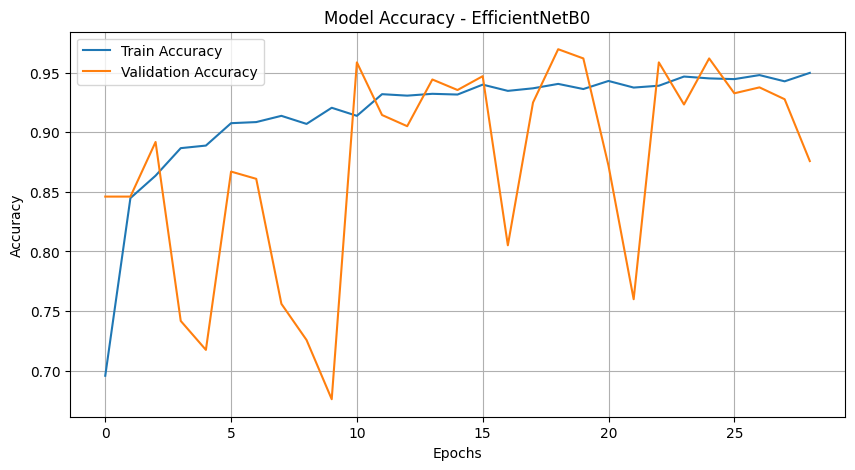

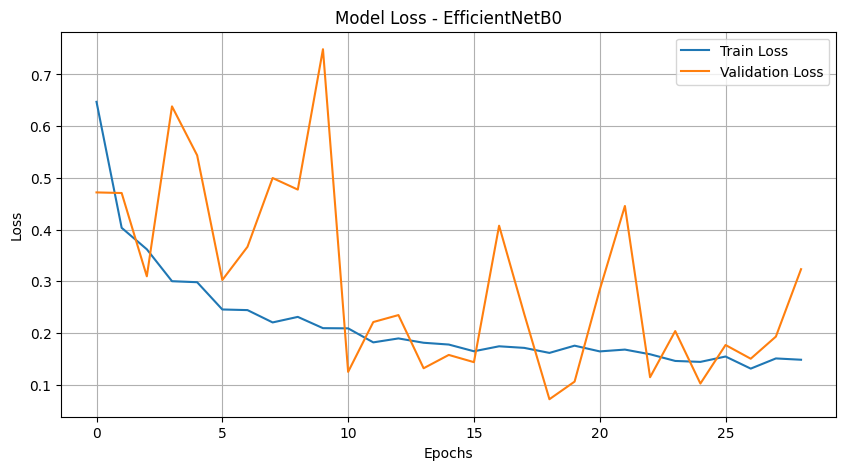

✅ Final model saved at: /content/drive/MyDrive/Research/Results_efficientnet/leukemia_final_model_efficientnet.keras


In [ ]:
# ======================================================
# 🧪 7. EVALUATION (BINARY CLASSIFICATION)
# ======================================================
from sklearn.metrics import roc_auc_score
import numpy as np

# Evaluate
test_loss, test_acc, test_precision, test_recall = model.evaluate(val_gen, verbose=1)

# F1 score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

# ROC-AUC for BINARY
y_true = val_gen.classes  # 0 or 1
y_pred_probs = model.predict(val_gen).ravel()  # Flatten predictions

roc_auc = roc_auc_score(y_true, y_pred_probs)

print("\n===== Validation Metrics =====")
print(f"Accuracy      : {test_acc:.4f}")
print(f"Loss          : {test_loss:.4f}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1 Score      : {test_f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")

# ======================================================
# 📊 8. LOG TRAINING RESULTS TO CSV
# ======================================================
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def safe_get(metric):
    return history.history.get(metric, [None])[-1]

row = [
    timestamp,
    safe_get('accuracy'),
    safe_get('val_accuracy'),
    safe_get('loss'),
    safe_get('val_loss'),
    safe_get('Precision'),
    safe_get('val_Precision'),
    safe_get('Recall'),
    safe_get('val_Recall'),
    max(history.history.get('val_accuracy', [0])),
    min(history.history.get('val_loss', [999])),
    test_acc, test_loss, test_precision, test_recall, test_f1, roc_auc,
    len(history.history.get('accuracy', [])),
    (safe_get('accuracy') or 0) - (safe_get('val_accuracy') or 0),
    model.count_params()
]

header = [
    'Timestamp','Train_Acc','Val_Acc','Train_Loss','Val_Loss',
    'Train_Precision','Val_Precision','Train_Recall','Val_Recall',
    'Best_Val_Acc','Best_Val_Loss',
    'Test_Acc','Test_Loss','Test_Precision','Test_Recall','Test_F1','Test_ROC_AUC',
    'Epochs_Trained','Overfitting_Gap','Total_Params'
]

# Create or append CSV
if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerow(row)
else:
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row)

print(f"✅ Metrics logged to {LOG_FILE}")

# ======================================================
# 📈 9. VISUALIZE TRAINING CURVES
# ======================================================
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy - EfficientNetB0')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss - EfficientNetB0')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# ======================================================
# 💾 10. SAVE FINAL MODEL (.keras FORMAT)
# ======================================================
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, 'leukemia_final_model_efficientnet.keras')
model.save(FINAL_MODEL_PATH)
print(f"✅ Final model saved at: {FINAL_MODEL_PATH}")


Please upload your image file:


Saving WBC-Malignant-Early-088.jpg to WBC-Malignant-Early-088.jpg
User uploaded file "WBC-Malignant-Early-088.jpg"


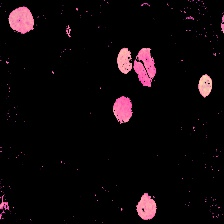

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Prediction for WBC-Malignant-Early-088.jpg:
Predicted Class: ALL Positive (Leukemia Detected)
Confidence: 78.23%


In [3]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt # Import matplotlib for displaying images

# Ensure the model is loaded (from previous steps, it should be in memory)
# If running this cell independently, you might need to load the model:
from tensorflow.keras.models import load_model

# Redefine RESULTS_DIR and FINAL_MODEL_PATH if running this cell independently
RESULTS_DIR = '/content/drive/MyDrive/Research/Results_efficientnet'
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, 'leukemia_final_model_efficientnet.keras')

model = load_model(FINAL_MODEL_PATH) # Assuming FINAL_MODEL_PATH is defined and correct

def predict_single_image(img_path, model, img_size=(224, 224)):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array /= 255.0  # Normalize to [0,1]

    prediction = model.predict(img_array)[0][0] # Get the single prediction value

    if prediction > 0.5:
        label = "ALL Positive (Leukemia Detected)"
        confidence = prediction * 100
    else:
        label = "ALL Negative (No Leukemia Detected)"
        confidence = (1 - prediction) * 100

    return label, confidence

print("Please upload your image file:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')

    # Get the image path
    img_path = fn

    # Display the uploaded image
    display(Image.open(img_path))

    # Make prediction
    # IMG_SIZE is also not defined in this cell if run independently, so we'll pass the default
    predicted_label, predicted_confidence = predict_single_image(img_path, model)

    print(f"\nPrediction for {fn}:")
    print(f"Predicted Class: {predicted_label}")
    print(f"Confidence: {predicted_confidence:.2f}%")